In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:98% !important;}
div.cell.code_cell.rendered{width:98%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:22pt;}
.inner_cell{font-size:22pt;}
div.text_cell_render pre code {font-size:22pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:22pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render li, div.text_cell_render p{width:95% !important;font-size:20pt;padding:5px; line-height:30px;}
table.dataframe{font-size:22px;}
table td, th{font-size:16px;}
table{ margin-left:0 !important;   /* 왼쪽 여백 0 */}
</style>
"""))

<font size="6" color="red"><b>ch4. 머신러닝 모형 최적화</b></font>
# 1절. 변수 선택과 차원 축소
## 1-1 변수선택과 차원축소
- 종속변수에 영향을 주는 변수들을 찾아 학습에 사용할 독립변수의 수를 줄임 (어떻게 하면 score를 높일 수 있을지?)
- 과적합과 변수들 사이의 다중공선성(변수들간 강한 상관관계)을 줄일 수 있음
* 회귀계수 해석이 어려워짐. 모델 예측력이 좋아도 해석력이 떨어짐(어떤 변수가 제일 큰 요인인지 잘), p값이나 유의성 검정이 왜곡될 수 있음
- 모형의 학습 시간을 줄일 수 있음
- 주성분분석, 상관분석, **분류모형의 feature_importance_, 예측 모형의 coef_**
- SelectKBest : 가장 높은 score에 따라 K개의 특징을 선택

## 1-2 주성분분석(PCA, Principal Component Analysis)
- 주성분분석은 변수 선택 및 차원축소 방법(기존의 모든 변수를 조합하여 새로운 변수로 만듦) 으로 널리 사용
- 주성분 분석은 상관관계가 있는 변수들을 선형결합해서 **분산이 극대화된 상관관계가 없는 새로운 변수(주성분)들로 축약**하는 것
- 주성분 분석은 사실 선형대수학이라기보다는 선형대수학의 활용적인 측면이 강하며 영상인식, 통계 데이터분석 (주성분 찾기), 데이터 압축, 노이즈제거 등 여러 분야에 사용
- 영상처리에서 많이 활용 : 여러개의 영상 중 대표 이미지를 찾을 때 활용

In [2]:
import seaborn as sns
from sklearn.decomposition import PCA
iris = sns.load_dataset('iris')
iris_X, iris_y = iris.iloc[:, :-1], iris.iloc[:, -1]
iris_X.shape, iris_y.shape

((150, 4), (150,))

In [3]:
# 다중공전성이 있는 독립변수 4개를 다중공전성전혀 없는 새로운 독립변수 2개로
pca = PCA(n_components=2) # n_components : 주성분 갯수
pca.fit(iris_X)
iris_pca = pca.transform(iris_X)
iris_pca[:3] # 주성분 2개

array([[-2.68412563,  0.31939725],
       [-2.71414169, -0.17700123],
       [-2.88899057, -0.14494943]])

In [4]:
import pandas as pd
df = pd.DataFrame(iris_pca, columns=['pca1', 'pca2'])
df.corr()

,pca1,pca2
pca1,1.000000e+00,5.494851e-16
pca2,5.494851e-16,1.000000e+00


In [5]:
# iris_X => df
pd.concat([iris_X, df], axis=1)

,sepal_length,sepal_width,petal_length,petal_width,pca1,pca2
0,5.1,3.5,1.4,0.2,-2.684126,0.319397
1,4.9,3.0,1.4,0.2,-2.714142,-0.177001
2,4.7,3.2,1.3,0.2,-2.888991,-0.144949
3,4.6,3.1,1.5,0.2,-2.745343,-0.318299
4,5.0,3.6,1.4,0.2,-2.728717,0.326755
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,1.944110,0.187532
146,6.3,2.5,5.0,1.9,1.527167,-0.375317
147,6.5,3.0,5.2,2.0,1.764346,0.078859
148,6.2,3.4,5.4,2.3,1.900942,0.116628


In [6]:
# 설명분산 : 각 주성분이 원 데이터정보량을 얼마나 잘 표현하는지 : 값이 클수록 더 중요한 주성분
pca.explained_variance_

array([4.22824171, 0.24267075])

In [7]:
pca.explained_variance_ratio_ 
# 0~1사이의 비율로 조정된 설명분산
# 2개의 주성분으로 전체 데이터(독립변수4)의 97.77% 정도 설명

array([0.92461872, 0.05306648])

In [8]:
pca.components_ # 주성분의 계수 : 각 주성분이 원래 특성들과 어떤 관계가 있는지의 가중치
# pca1 = 0.36138659*x0 -0.08452251*x1 + 0.85667061*x2 + 0.3582892*x3
# pca2 = 0.65658877*x0 + 0.73016143*x1 - 0.17337266*x2 - 0.07548102*x3

array([[ 0.36138659, -0.08452251,  0.85667061,  0.3582892 ],
       [ 0.65658877,  0.73016143, -0.17337266, -0.07548102]])

## 1-3 상관관계 확인
- 타겟변수와 상관관계가 높은 독립변수들만 선택


In [9]:
# redwine = pd.read_csv('data/winequality-red.csv', sep=';')
redwine = pd.read_csv('data/winequality-red.csv', delimiter=';')
redwine.sample()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
537,8.1,0.825,0.24,2.1,0.084,5.0,13.0,0.9972,3.37,0.77,10.7,6


- cmap의 종류 : https://jrc-park.tistory.com/155
- http://seaborn.pydata.org/generated/seaborn.heatmap.html#seaborn.heatmap
- http://seaborn.pydata.org/examples/many_pairwise_correlations.html

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['figure.figsize'] = (20, 4)

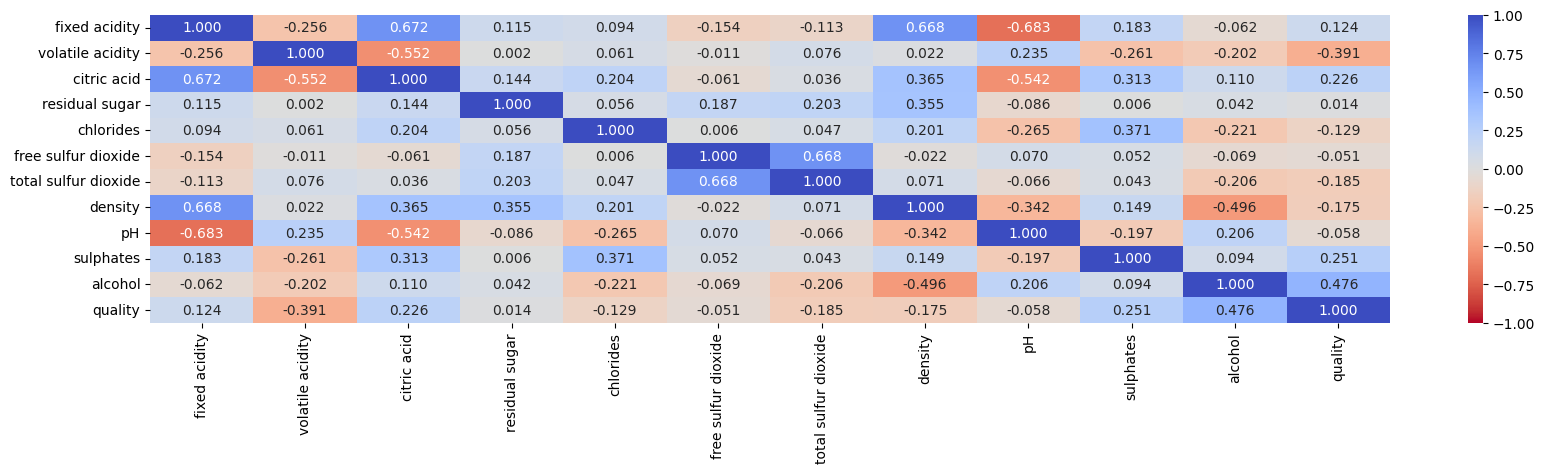

In [11]:
corr = redwine.corr()
#corr
sns.heatmap(corr, annot=True, fmt='.3f', vmin=-1, vmax=1, cmap='coolwarm_r')
plt.show()

In [12]:
mask = np.tril(np.ones_like(corr), k=0) # 대각선 포함 아래가 1인 삼각행렬(기본값0)
mask

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])

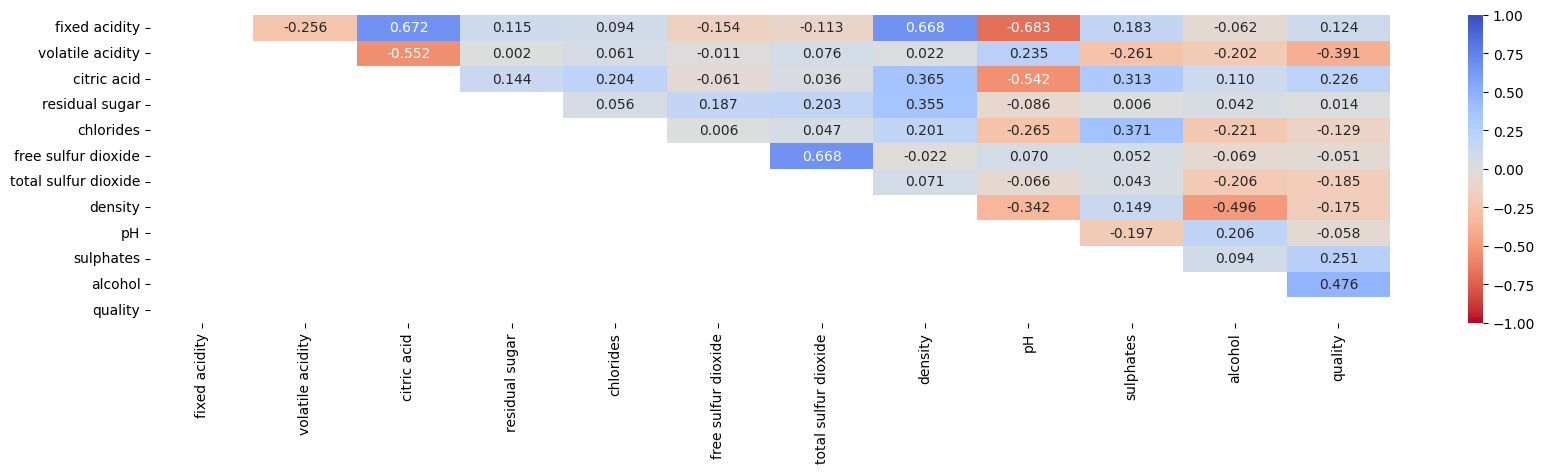

In [14]:
sns.heatmap(corr, annot=True, fmt='.3f', vmin=-1, vmax=1, cmap='coolwarm_r', mask=mask)
plt.show()

## 1-4 분류모형의 feature_importance_
- 모형의 feature_importance_ 속성은 독립변수들이 종속변수에 영향을 주는 정도를 저장
- DecisionTreeClassifier, RandomForestClassifier(tree계열), GradientBoostingClassifier, XGBclassifier,
  LGBMclassifier, CatBoostClassifier
- LogisticRegression이나 SVC, MLPclassifier, MultinomialNB등은 feature_importance_없음

In [15]:
X = redwine.iloc[:, :-1].to_numpy()
y = redwine.iloc[:, -1].values
from sklearn.model_selection import train_test_split
train_X, test_X, train_y, test_y = train_test_split(X, y,
                                                   test_size=0.3,
                                                   stratify=y) # 층화추출
train_X.shape, train_y.shape, test_X.shape, test_y.shape, type(train_X)

((1119, 11), (1119,), (480, 11), (480,), numpy.ndarray)

In [16]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=10,
                                 random_state=10)
rf_model.fit(train_X, train_y)

RandomForestClassifier(n_estimators=10, random_state=10)

In [17]:
features = pd.DataFrame(np.c_[redwine.columns[:-1],
                            rf_model.feature_importances_],
                       columns=['feature', 'importance'])
features['importance'].sum()

0.9999999999999998

In [18]:
features.sort_values(by='importance', ascending=False, inplace=True)
features

,feature,importance
10,alcohol,0.158497
9,sulphates,0.111432
6,total sulfur dioxide,0.109968
1,volatile acidity,0.095191
8,pH,0.082831
2,citric acid,0.081669
7,density,0.078536
0,fixed acidity,0.076646
4,chlorides,0.071974
3,residual sugar,0.071779


### feature_importance_를 이용한 변수 중요도 시각화

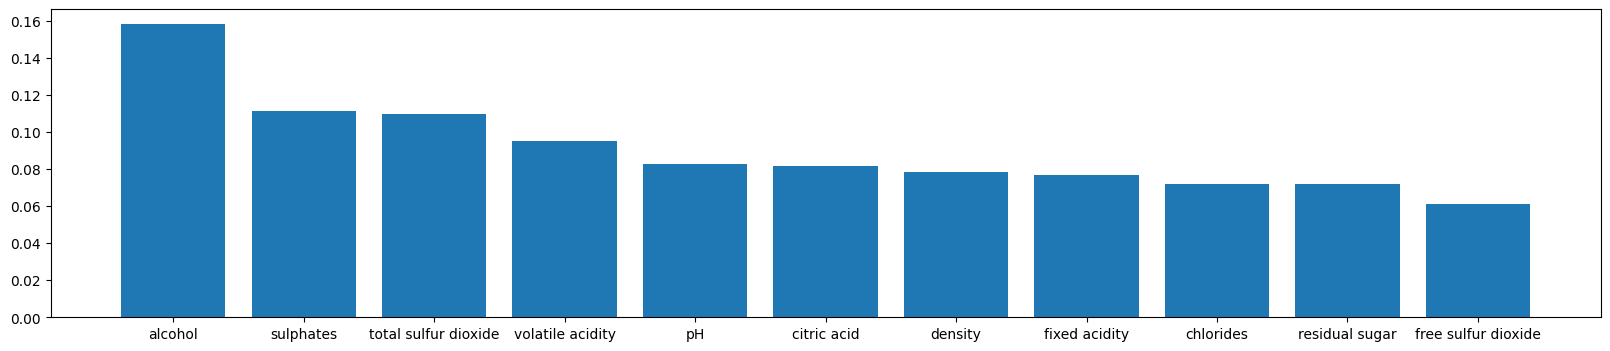

In [19]:
plt.bar(features.feature, features.importance)
plt.show()

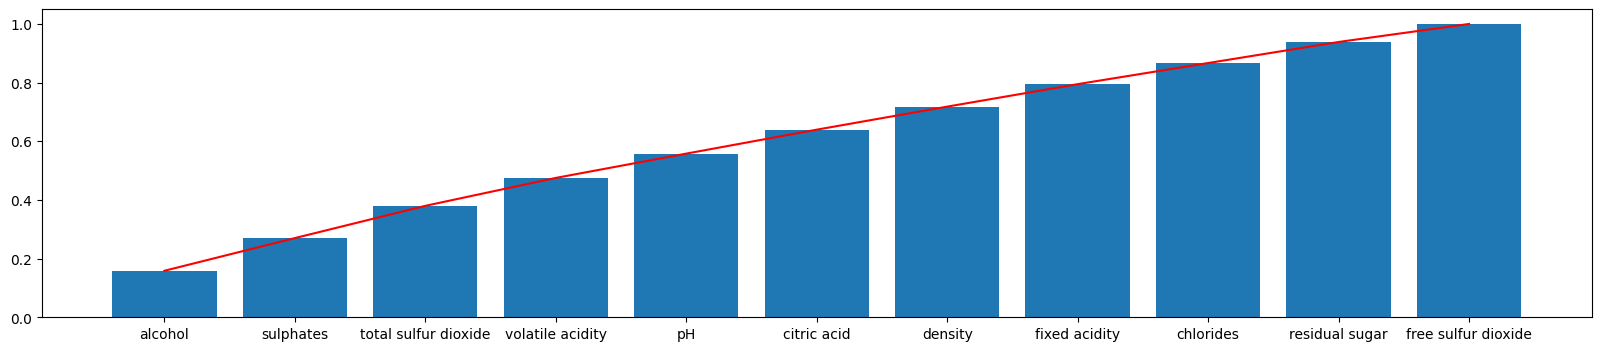

In [20]:
# 누적합을 이용한 시각화
y_stack = np.cumsum(features.importance) # importance 누적
# y_stack 
plt.bar(features.feature, y_stack)
plt.plot(features.feature, y_stack, c='r')
plt.show()

### RFE(Recursive Feature Elimination) 방식
- 중요도에 따라 낮은 변수부터 하나씩 제거해 나가면서 최종적으로 선택하고자 하는 변수의 갯수만큼 남긴다

In [24]:
# 5개의 특징이 남을 때까지 변수를 제거(기준 : feature_importance_)
from sklearn.feature_selection import RFE
rfe_model = RFE(#RandomForestClassifier(n_estimators=10, random_state=10)
    rf_model,
    n_features_to_select=5
)
rfe_model.fit(train_X, train_y)
# rfe_model.get_support()
features_rfe = pd.DataFrame(np.c_[redwine.columns[:-1],
                                 rfe_model.get_support()],
                           columns=['feature', 'selected'])
features_rfe.sort_values(by='selected', ascending=False)

,feature,selected
1,volatile acidity,True
6,total sulfur dioxide,True
7,density,True
9,sulphates,True
10,alcohol,True
0,fixed acidity,False
2,citric acid,False
3,residual sugar,False
4,chlorides,False
5,free sulfur dioxide,False
